**Instalasi Library**
1. networkx

    Fungsi : untuk membangun dan memanipulasi struktur graf

2. matplotlib

    Fungsi : menampilkan secara visual

In [3]:
!pip install networkx matplotlib

  Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)


ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\plont\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\contourpy\\enum_util.py'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Algoritma dijkstra sederhana

In [ ]:
def dijkstra(graph, start):
    distance = {node: float('inf') for node in graph}
    distance[start] = 0
    visited = set()
    
    while len(visited) < len(graph):
        current = min((node for node in graph if node not in visited), key=lambda node: distance[node])
        visited.add(current)
        for neighbor, weigh in graph[current].items():
            if distance[current] + weigh < distance[neighbor]:
                distance[neighbor] = distance[current] + weigh
    return distance

Struktur Data Graf dan Algoritma

jarak terpendek dari A ke D: 4
jalur: A->B->C->D


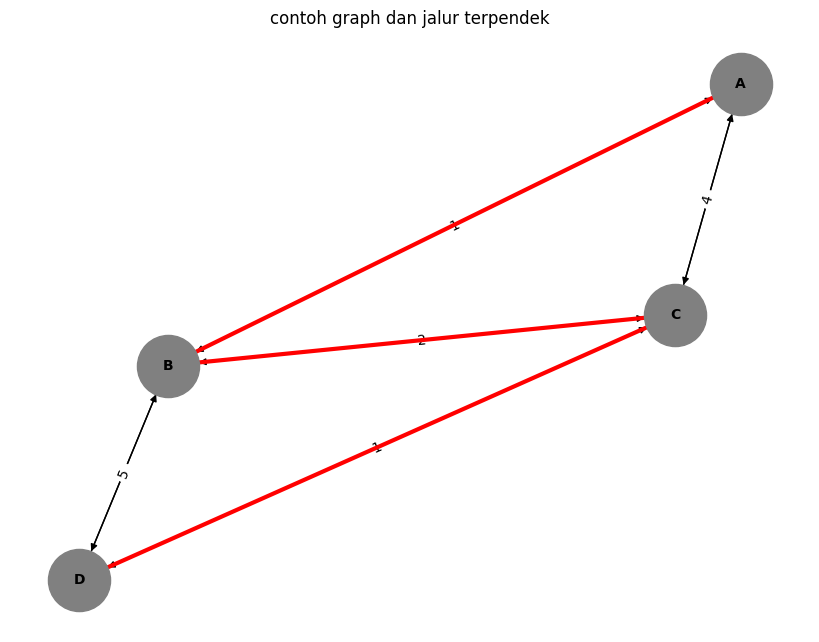

In [ ]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dikjkstra_algorithm(graph_as_dictionary, first_node):
    distances_dictionary = {node: float('inf') for node in graph_as_dictionary}     # Menginisiasi jarak seluruh node dengan nilai tak hingga (infinite) sebagai nilai standar awal
    distances_dictionary[first_node] = 0        # Mengatur jarak untuk node awal (start node) menjadi 0 karena dimulai dari titik tersebut
    previous = {node: None for node in graph_as_dictionary}     # Mengisi semua node pelacak jalur sebelumnya dengan status None (belum ada jalur terpilih)
    queue = [(0, first_node)]       # Membuat antrean berprioritas (priority queue) dan memasukkan node awal dengan bobot/jarak 0
    while queue:    
        current_distance, current_node = heapq.heappop(queue)       # Mengambil node dengan jarak terkecil saat ini dari priority queue (konsep min-heap)
        for neighbor, weight in graph_as_dictionary[current_node].items():   
            distance = current_distance + weight   
            if distance < distances_dictionary[neighbor]:    
                distances_dictionary[neighbor] = distance       # Memperbarui catatan jarak terpendek ke node tetangga tersebut dengan jarak yang baru
                previous[neighbor] = current_node       # Memperbarui pointer jalur untuk mencatat bahwa node saat ini adalah pendahulu dari tetangga tersebut 
                heapq.heappush(queue, (distance, neighbor))     # Memasukkan kembali tetangga ke dalam priority queue dengan bobot jarak yang baru untuk diperiksa nanti
    return distances_dictionary, previous   

# =============== fungsi untuk merekonstruksi jalur ===============
def get_path(previous, target_node):   
    path = []   
    current_node = target_node   
    while current_node is not None:   
        path.insert(0, current_node)        # Memasukkan node saat ini ke bagian paling depan list (indeks 0) agar urutannya menjadi maju saat dibaca
        current_node = previous[current_node]       # Menggeser posisi mundur ke node pendahulu berikutnya dengan mengikuti pointer di dictionary previous
    return path 

# =============== visualisasi dengan networkx dan matplotlib ===============
def visual(graph, path=None):    
    graph_for_visual = nx.DiGraph()     # Membuat objek graf berarah kosong menggunakan library NetworkX
    for node in graph:
        for neighbor, weight in graph[node].items():
            graph_for_visual.add_edge(node, neighbor, weight=weight)        # Menambahkan relasi garis (edge) antar node beserta bobotnya ke dalam objek visualisasi
    pos = nx.spring_layout(graph_for_visual)        # Mengatur susunan posisi node secara otomatis menggunakan algoritma spring layout agar rapi
    edge_labels = nx.get_edge_attributes(graph_for_visual, 'weight')        # Mengambil properti bobot (weight) dari setiap garis untuk dijadikan label teks nantinya
    plt.figure(figsize=(8, 6))
    nx.draw(graph_for_visual, pos, with_labels=True, node_size=2000, node_color='gray', font_size=10, font_color='black', font_weight='bold', arrows=True)
    nx.draw_networkx_edge_labels(graph_for_visual, pos, edge_labels=edge_labels)
    if path and len(path) > 1:
        path_edge = list(zip(path, path[1:]))       # Memasangkan node secara berurutan (misal: ['A','B','C'] menjadi [('A','B'), ('B','C')]) untuk mendeteksi garis jalur
        nx.draw_networkx_edges(graph_for_visual, pos, edgelist=path_edge, edge_color='red', width=3) # Menggambar ulang garis yang dilewati oleh jalur terpendek dengan warna merah tebal
    plt.title("contoh graph dan jalur terpendek")
    plt.axis('off')         # Menghilangkan garis sumbu koordinat (X dan Y) agar tampilan graf bersih
    plt.show()

# =============== use ===============
# Mendefinisikan struktur graf menggunakan representasi Adjacency List berbentuk Dictionary Python
graph_as_dictionary = {
    'A': {'B': 1, 'C': 4},
    'B': {'A': 1, 'C': 2, 'D': 5},
    'C': {'A': 4, 'B': 2, 'D': 1},
    'D': {'B': 5, 'C': 1}
}
start_node = 'A'
end_node = 'D'
distances, previous = dikjkstra_algorithm(graph_as_dictionary, start_node)
shortest_path = get_path(previous, end_node)
print(f"jarak terpendek dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"jalur: {'->'.join(shortest_path)}")
visual(graph_as_dictionary, path=shortest_path)

- Modifikasi Graph agar memiliki siklus dan ulangi visualnya

jarak terpendek dari A ke D: 4
jalur: A->B->C->D


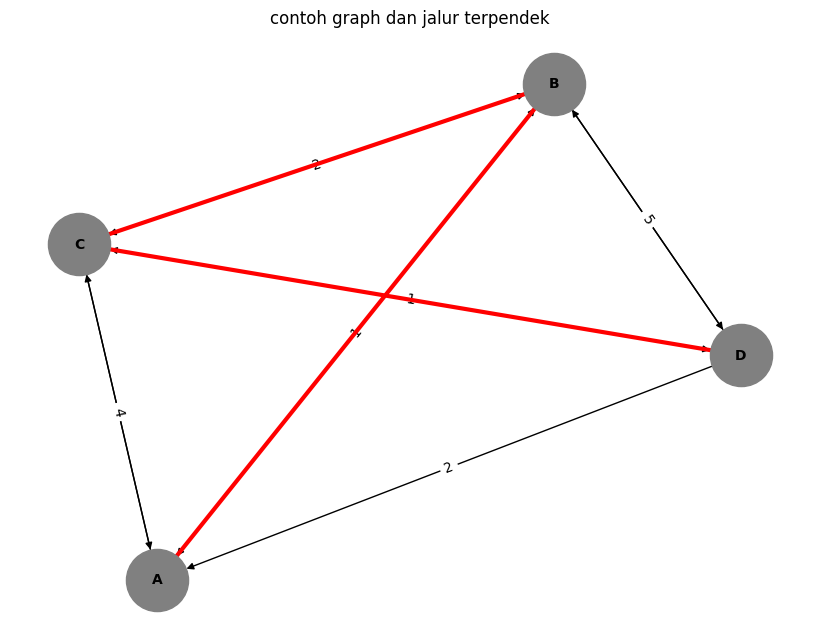

In [29]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dikjkstra_algorithm(graph_as_dictionary, first_node):
    distances_dictionary = {node: float('inf') for node in graph_as_dictionary}     # Menginisiasi jarak seluruh node dengan nilai tak hingga (infinite) sebagai nilai standar awal
    distances_dictionary[first_node] = 0        # Mengatur jarak untuk node awal (start node) menjadi 0 karena dimulai dari titik tersebut
    previous = {node: None for node in graph_as_dictionary}     # Mengisi semua node pelacak jalur sebelumnya dengan status None (belum ada jalur terpilih)
    queue = [(0, first_node)]       # Membuat antrean berprioritas (priority queue) dan memasukkan node awal dengan bobot/jarak 0
    while queue:    
        current_distance, current_node = heapq.heappop(queue)       # Mengambil node dengan jarak terkecil saat ini dari priority queue (konsep min-heap)
        for neighbor, weight in graph_as_dictionary[current_node].items():   
            distance = current_distance + weight   
            if distance < distances_dictionary[neighbor]:    
                distances_dictionary[neighbor] = distance       # Memperbarui catatan jarak terpendek ke node tetangga tersebut dengan jarak yang baru
                previous[neighbor] = current_node       # Memperbarui pointer jalur untuk mencatat bahwa node saat ini adalah pendahulu dari tetangga tersebut 
                heapq.heappush(queue, (distance, neighbor))     # Memasukkan kembali tetangga ke dalam priority queue dengan bobot jarak yang baru untuk diperiksa nanti
    return distances_dictionary, previous   

# =============== fungsi untuk merekonstruksi jalur ===============
def get_path(previous, target_node):   
    path = []   
    current_node = target_node   
    while current_node is not None:   
        path.insert(0, current_node)        # Memasukkan node saat ini ke bagian paling depan list (indeks 0) agar urutannya menjadi maju saat dibaca
        current_node = previous[current_node]       # Menggeser posisi mundur ke node pendahulu berikutnya dengan mengikuti pointer di dictionary previous
    return path 

# =============== visualisasi dengan networkx dan matplotlib ===============
def visual(graph, path=None):    
    graph_for_visual = nx.DiGraph()     # Membuat objek graf berarah kosong menggunakan library NetworkX
    for node in graph:
        for neighbor, weight in graph[node].items():
            graph_for_visual.add_edge(node, neighbor, weight=weight)        # Menambahkan relasi garis (edge) antar node beserta bobotnya ke dalam objek visualisasi
    pos = nx.spring_layout(graph_for_visual)        # Mengatur susunan posisi node secara otomatis menggunakan algoritma spring layout agar rapi
    # Mengambil properti bobot (weight) dari setiap garis untuk dijadikan label teks nantinya
    edge_labels = nx.get_edge_attributes(graph_for_visual, 'weight')
    plt.figure(figsize=(8, 6))
    nx.draw(graph_for_visual, pos, with_labels=True, node_size=2000, node_color='gray', font_size=10, font_color='black', font_weight='bold', arrows=True)
    nx.draw_networkx_edge_labels(graph_for_visual, pos, edge_labels=edge_labels)
    if path and len(path) > 1:
        path_edge = list(zip(path, path[1:]))       # Memasangkan node secara berurutan (misal: ['A','B','C'] menjadi [('A','B'), ('B','C')]) untuk mendeteksi garis jalur
        nx.draw_networkx_edges(graph_for_visual, pos, edgelist=path_edge, edge_color='red', width=3) # Menggambar ulang garis yang dilewati oleh jalur terpendek dengan warna merah tebal
    plt.title("contoh graph dan jalur terpendek")
    plt.axis('off')         # Menghilangkan garis sumbu koordinat (X dan Y) agar tampilan graf bersih
    plt.show()

# =============== use ===============
# Mendefinisikan struktur graf menggunakan representasi Adjacency List berbentuk Dictionary Python
graph_as_dictionary = {
    'A': {'B': 1, 'C': 4},
    'B': {'A': 1, 'C': 2, 'D': 5},
    'C': {'A': 4, 'B': 2, 'D': 1},
    'D': {'B': 5, 'C': 1, 'A': 2}
}
start_node = 'A'
end_node = 'D'
distances, previous = dikjkstra_algorithm(graph_as_dictionary, start_node)
shortest_path = get_path(previous, end_node)
print(f"jarak terpendek dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"jalur: {'->'.join(shortest_path)}")
visual(graph_as_dictionary, path=shortest_path)

- Tambahkan simpul baru dan lihat bagaimana jalur terpendek berubah

jarak terpendek dari A ke D: 4
jalur: A->B->C->D


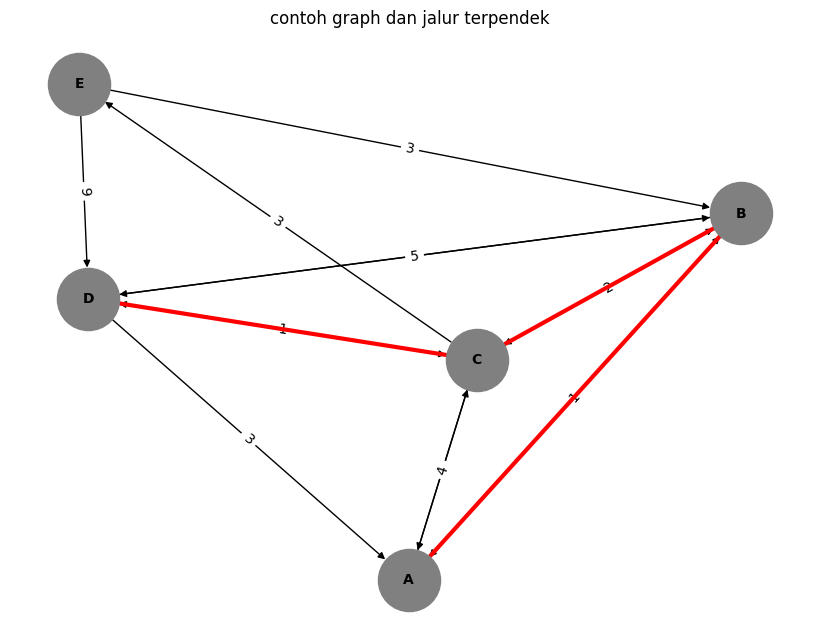

In [54]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dikjkstra_algorithm(graph_as_dictionary, first_node):
    distances_dictionary = {node: float('inf') for node in graph_as_dictionary}     # Menginisiasi jarak seluruh node dengan nilai tak hingga (infinite) sebagai nilai standar awal
    distances_dictionary[first_node] = 0        # Mengatur jarak untuk node awal (start node) menjadi 0 karena dimulai dari titik tersebut
    previous = {node: None for node in graph_as_dictionary}     # Mengisi semua node pelacak jalur sebelumnya dengan status None (belum ada jalur terpilih)
    queue = [(0, first_node)]       # Membuat antrean berprioritas (priority queue) dan memasukkan node awal dengan bobot/jarak 0
    while queue:    
        current_distance, current_node = heapq.heappop(queue)       # Mengambil node dengan jarak terkecil saat ini dari priority queue (konsep min-heap)
        for neighbor, weight in graph_as_dictionary[current_node].items():   
            distance = current_distance + weight   
            if distance < distances_dictionary[neighbor]:    
                distances_dictionary[neighbor] = distance       # Memperbarui catatan jarak terpendek ke node tetangga tersebut dengan jarak yang baru
                previous[neighbor] = current_node       # Memperbarui pointer jalur untuk mencatat bahwa node saat ini adalah pendahulu dari tetangga tersebut 
                heapq.heappush(queue, (distance, neighbor))     # Memasukkan kembali tetangga ke dalam priority queue dengan bobot jarak yang baru untuk diperiksa nanti
    return distances_dictionary, previous   

# =============== fungsi untuk merekonstruksi jalur ===============
def get_path(previous, target_node):   
    path = []   
    current_node = target_node   
    while current_node is not None:   
        path.insert(0, current_node)        # Memasukkan node saat ini ke bagian paling depan list (indeks 0) agar urutannya menjadi maju saat dibaca
        current_node = previous[current_node]       # Menggeser posisi mundur ke node pendahulu berikutnya dengan mengikuti pointer di dictionary previous
    return path 

# =============== visualisasi dengan networkx dan matplotlib ===============
def visual(graph, path=None):    
    graph_for_visual = nx.DiGraph()     # Membuat objek graf berarah kosong menggunakan library NetworkX
    for node in graph:
        for neighbor, weight in graph[node].items():
            graph_for_visual.add_edge(node, neighbor, weight=weight)        # Menambahkan relasi garis (edge) antar node beserta bobotnya ke dalam objek visualisasi
    pos = nx.spring_layout(graph_for_visual)        # Mengatur susunan posisi node secara otomatis menggunakan algoritma spring layout agar rapi
    # Mengambil properti bobot (weight) dari setiap garis untuk dijadikan label teks nantinya
    edge_labels = nx.get_edge_attributes(graph_for_visual, 'weight')
    plt.figure(figsize=(8, 6))
    nx.draw(graph_for_visual, pos, with_labels=True, node_size=2000, node_color='gray', font_size=10, font_color='black', font_weight='bold', arrows=True)
    nx.draw_networkx_edge_labels(graph_for_visual, pos, edge_labels=edge_labels)
    if path and len(path) > 1:
        path_edge = list(zip(path, path[1:]))       # Memasangkan node secara berurutan (misal: ['A','B','C'] menjadi [('A','B'), ('B','C')]) untuk mendeteksi garis jalur
        nx.draw_networkx_edges(graph_for_visual, pos, edgelist=path_edge, edge_color='red', width=3) # Menggambar ulang garis yang dilewati oleh jalur terpendek dengan warna merah tebal
    plt.title("contoh graph dan jalur terpendek")
    plt.axis('off')         # Menghilangkan garis sumbu koordinat (X dan Y) agar tampilan graf bersih
    plt.show()

# =============== use ===============
# Mendefinisikan struktur graf menggunakan representasi Adjacency List berbentuk Dictionary Python
graph_as_dictionary = {
    'A': {'B': 1, 'C': 4},
    'B': {'A': 1, 'C': 2, 'D': 5},
    'C': {'A': 4, 'B': 2, 'D': 1, 'E': 3},  
    'D': {'B': 5, 'C': 1, 'A': 3},
    'E': {'D': 9, 'B': 3}                     
}
start_node = 'A'
end_node = 'D'
distances, previous = dikjkstra_algorithm(graph_as_dictionary, start_node)
shortest_path = get_path(previous, end_node)
print(f"jarak terpendek dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"jalur: {'->'.join(shortest_path)}")
visual(graph_as_dictionary, path=shortest_path)

- Ganti tata letak graph dengan code pos = nx.circular_layout(G) atau kamada_kawai_layout

jarak terpendek dari A ke D: 4
jalur: A->B->C->D


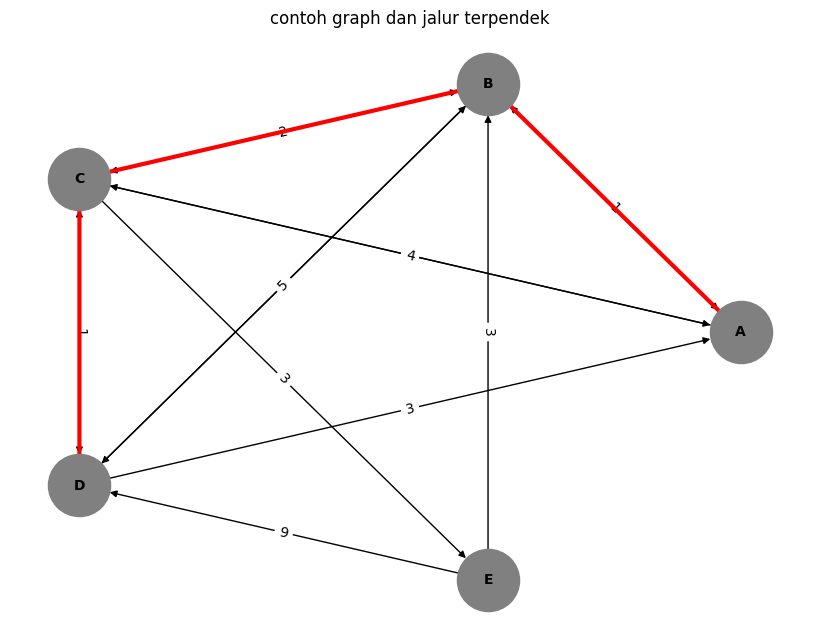

In [ ]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dikjkstra_algorithm(graph_as_dictionary, first_node):
    distances_dictionary = {node: float('inf') for node in graph_as_dictionary}     # Menginisiasi jarak seluruh node dengan nilai tak hingga (infinite) sebagai nilai standar awal
    distances_dictionary[first_node] = 0        # Mengatur jarak untuk node awal (start node) menjadi 0 karena dimulai dari titik tersebut
    previous = {node: None for node in graph_as_dictionary}     # Mengisi semua node pelacak jalur sebelumnya dengan status None (belum ada jalur terpilih)
    queue = [(0, first_node)]       # Membuat antrean berprioritas (priority queue) dan memasukkan node awal dengan bobot/jarak 0
    while queue:    
        current_distance, current_node = heapq.heappop(queue)       # Mengambil node dengan jarak terkecil saat ini dari priority queue (konsep min-heap)
        for neighbor, weight in graph_as_dictionary[current_node].items():   
            distance = current_distance + weight   
            if distance < distances_dictionary[neighbor]:    
                distances_dictionary[neighbor] = distance       # Memperbarui catatan jarak terpendek ke node tetangga tersebut dengan jarak yang baru
                previous[neighbor] = current_node       # Memperbarui pointer jalur untuk mencatat bahwa node saat ini adalah pendahulu dari tetangga tersebut 
                heapq.heappush(queue, (distance, neighbor))     # Memasukkan kembali tetangga ke dalam priority queue dengan bobot jarak yang baru untuk diperiksa nanti
    return distances_dictionary, previous   

# =============== fungsi untuk merekonstruksi jalur ===============
def get_path(previous, target_node):   
    path = []   
    current_node = target_node   
    while current_node is not None:   
        path.insert(0, current_node)        # Memasukkan node saat ini ke bagian paling depan list (indeks 0) agar urutannya menjadi maju saat dibaca
        current_node = previous[current_node]       # Menggeser posisi mundur ke node pendahulu berikutnya dengan mengikuti pointer di dictionary previous
    return path 

# =============== visualisasi dengan networkx dan matplotlib ===============
def visual(graph, path=None, layout_type="circular"):    
    graph_for_visual = nx.DiGraph()     # Membuat objek graf berarah kosong menggunakan library NetworkX
    for node in graph:
        for neighbor, weight in graph[node].items() :
            graph_for_visual.add_edge(node, neighbor, weight=weight)        # Menambahkan relasi garis (edge) antar node beserta bobotnya ke dalam objek visualisasi
    pos = nx.spring_layout(graph_for_visual)        # Mengatur susunan posisi node secara otomatis menggunakan algoritma spring layout agar rapi
    if layout_type == "circular":
        pos = nx.circular_layout(graph_for_visual)
        title = "Graph - Circular Layout"
    elif layout_type == "kamada_kawai" :
        pos = nx.kamada_kawai_layout(graph_for_visual)
        title = "Graph - Kamada Kawai Layout"
    else :  
        pos = nx.spring_layout(graph_for_visual, seed=42)
        title = "Graph - Spring Layout"
    edge_labels = nx.get_edge_attributes(graph_for_visual, 'weight')
    plt.figure(figsize=(8, 6))
    nx.draw(graph_for_visual, pos, with_labels=True, node_size=2000, node_color='gray', font_size=10, font_color='black', font_weight='bold', arrows=True)
    nx.draw_networkx_edge_labels(graph_for_visual, pos, edge_labels=edge_labels)
    if path and len(path) > 1:
        path_edge = list(zip(path, path[1:]))       # Memasangkan node secara berurutan (misal: ['A','B','C'] menjadi [('A','B'), ('B','C')]) untuk mendeteksi garis jalur
        nx.draw_networkx_edges(graph_for_visual, pos, edgelist=path_edge, edge_color='red', width=3) # Menggambar ulang garis yang dilewati oleh jalur terpendek dengan warna merah tebal
    plt.title("contoh graph dan jalur terpendek")
    plt.axis('off')         # Menghilangkan garis sumbu koordinat (X dan Y) agar tampilan graf bersih
    plt.show()

# =============== use ===============
# Mendefinisikan struktur graf menggunakan representasi Adjacency List berbentuk Dictionary Python
graph_as_dictionary = {
    'A': {'B': 1, 'C': 4},
    'B': {'A': 1, 'C': 2, 'D': 5},
    'C': {'A': 4, 'B': 2, 'D': 1, 'E': 3},  
    'D': {'B': 5, 'C': 1, 'A': 3},
    'E': {'D': 9, 'B': 3}                     
}
start_node = 'A'
end_node = 'D'
distances, previous = dikjkstra_algorithm(graph_as_dictionary, start_node)
shortest_path = get_path(previous, end_node)
print(f"jarak terpendek dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"jalur: {'->'.join(shortest_path)}")
visual(graph_as_dictionary, path=shortest_path)